# Vergleich zwischen allen Modellen

# 1 Preprocessing

## 1.1 Imports

In [2]:
import os
import pandas as pd
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
from openpyxl import load_workbook

## 1.2 Einlesen aller Daten

In [3]:
# Arbeitsverzeichnis (FENES_P2X)
current_dir = os.getcwd()

# Hilfsfunktion zum Erkennen ungültiger Namen (z. B. Leerzeichen, Minus etc.)
def sanitize_name(name):
    return name.replace("-", "_").replace(" ", "_").replace("ä", "ae").replace("ö", "oe").replace("ü", "ue").replace("ß", "ss")

# Gehe durch alle Technologieordner (z. B. Methanol, Ammoniak, Fischer_Tropsch)
for technologie in os.listdir(current_dir):
    tech_path = os.path.join(current_dir, technologie)

    if not os.path.isdir(tech_path):
        continue

    for folder in os.listdir(tech_path):
        folder_path = os.path.join(tech_path, folder)

        if not os.path.isdir(folder_path):
            continue

        if re.search(r"vergleich|sensitiv|Methanol_Bio_H2_Brownfield_Memmingen", folder.lower()):
            print(f"⚠️  Übersprungen: {folder}")
            continue

        csv_path = os.path.join(folder_path, "Ergebnisse.csv")
        if os.path.isfile(csv_path):
            try:
                df = pd.read_csv(csv_path, sep=';', decimal=',')

                # Variable direkt erstellen
                var_name = sanitize_name(folder)
                globals()[var_name] = df.set_index("Variable")["Wert"]

                print(f"✅ {var_name} geladen mit {len(df)} Zeilen.")
            except Exception as e:
                print(f"❌ Fehler bei {csv_path}: {e}")
        else:
            print(f"⚠️  Keine Ergebnisse.csv in {folder_path}")



⚠️  Keine Ergebnisse.csv in c:\Users\hem38994\Documents\GitHub\FENES_P2X\.git\hooks
⚠️  Keine Ergebnisse.csv in c:\Users\hem38994\Documents\GitHub\FENES_P2X\.git\info
⚠️  Keine Ergebnisse.csv in c:\Users\hem38994\Documents\GitHub\FENES_P2X\.git\lfs
⚠️  Keine Ergebnisse.csv in c:\Users\hem38994\Documents\GitHub\FENES_P2X\.git\logs
⚠️  Keine Ergebnisse.csv in c:\Users\hem38994\Documents\GitHub\FENES_P2X\.git\objects
⚠️  Keine Ergebnisse.csv in c:\Users\hem38994\Documents\GitHub\FENES_P2X\.git\refs
⚠️  Übersprungen: Ammoniak_Sensitivität
⚠️  Übersprungen: Ammoniak_Vergleich
✅ Hoechst_1_Ammoniak_Greenfield geladen mit 110 Zeilen.
✅ Hoechst_2_Ammoniak_Brownfield geladen mit 110 Zeilen.
✅ Hoechst_3_Ammoniak_Brownfield_H2 geladen mit 112 Zeilen.
✅ Hoechst_4_Ammoniak_Brownfield_H2_N2 geladen mit 115 Zeilen.
✅ Hoechst_5_Ammoniak_Brownfield_H2_N2_HB geladen mit 115 Zeilen.
✅ Hoechst_6_Ammoniak_Greenfield_HB geladen mit 110 Zeilen.
✅ Leuna_1_Ammoniak_Greenfield geladen mit 110 Zeilen.
✅ Leuna_2_A

## 1.3 Farbvorgaben

In [4]:
col_n2 = col_asu = "#e5742e"                # Corporate orange              oder Gas orange: "#e4932c"
col_pv = "#e4cb3a"                          # PV Gelb
col_wka = "#128fcf"                         # WKA Blau
col_h2 = col_pem = "#14689b"                # Corporate Blau                oder Wasser blau: "#1b5aa6"
col_nh3 = col_hb = "#822181"                # Corporate Lila                oder Fern/Nahwärme Lila: "#8f2f89"
col_h2s = "#79CADD"                         #Corporate Hellblau Alternativ: Stromsektor Rot  #E02229             bzw Gasspeicher rot
col_bat = "#8CBF3E"                         # ElChem Speicher grün
col_buy = "#505050"
col_chem = "#1D9838"              # Biomasse Grün
col_etc = "#828282"                         # Corporate Grau

col_co2 = col_mea = col_dac = "#050505"               # Diesel grau
col_saf = col_ft = "#c796c4"                # Coorporate lila blass
col_ch4 = col_mg = "#e4932c"           
col_el= col_sell = "#E02229"                # Stromsektor Rot
col_q = col_hp = "#B01920"                  # Dunkelrot (Geothermie rot) 
col_qs = "#B96428"                          # Braunkohle braun
col_naph = "#DADADA"                        # Coorporate grau blass
col_bio = "#C796C4"                         # Coorporate Lila blass

col_ch3oh = col_ms = "#e5742e"              # Gas orange                

## 1.4 Funktionen

### 1.4.1 Modellvergleich Balken

In [5]:
def plot_modelvergleich(parameter, farbe, xlim, ylim, save_path,
                        xlabel="Wert", title="Modellvergleich", multiplikator=1,
                        benchmark_prices=None):

    # Definiere die Technologie-Reihenfolge
    tech_order = ["Methane","Ammoniak", "Methanol", "FischerTropsch"]

    # Technologie zuordnen
    def get_tech(name):
        for tech in tech_order:
            if name.startswith(tech) or name.endswith(tech):
                return tech
        return "Sonstige"


    modelle = {
        name: globals()[name]
        for name in globals()
        if isinstance(globals()[name], pd.Series)
        and parameter in globals()[name]
        and get_tech(name) in tech_order  # nur bekannte Gruppen
    }

    # Benchmarks als zusätzliche Serien einfügen
    if benchmark_prices:
        for tech, value in benchmark_prices.items():
            benchmark_name = f"Benchmark {tech}"
            modelle[benchmark_name] = pd.Series({parameter: value})



    if not modelle:
        print(f"⚠️ Keine Modelle mit Parameter '{parameter}' gefunden.")
        return

    # Sortieren: erst nach tech_order, dann nach -Wert
    modelle_sortiert = sorted(
        modelle.items(),
        key=lambda item: (
            tech_order.index(get_tech(item[0])),
            -item[1][parameter]
        )
    )
    
    
    # # Sortieren: nach tech_order, dann nach Länge des Modellnamens (aufsteigend)
    # modelle_sortiert = sorted(
    #     modelle.items(),
    #     key=lambda item: (
    #         tech_order.index(get_tech(item[0])),
    #         len(item[0])
    #     )
    # )

    # Extrahieren
    categories = list(name for name, _ in modelle_sortiert)
    values = [model[parameter] * multiplikator for _, model in modelle_sortiert]
    # values = [model[parameter] for _, model in modelle_sortiert]
    #colors = [farbe] * len(values)

    colors = []
    for name, _ in modelle_sortiert:
        if name.startswith("Benchmark"):
            colors.append("lightgray")  # oder z. B. "#999999"
        else:
            colors.append(farbe)


    # Trennlinien berechnen
    lines_and_labels = []
    last_tech = get_tech(categories[0])
    for i, name in enumerate(categories[1:], 1):
        tech = get_tech(name)
        if tech != last_tech:
            lines_and_labels.append((i - 0.5, tech))
            last_tech = tech

    # Gruppenbereiche für Hintergrund
    group_ranges = []
    last_tech = get_tech(categories[0])
    start = 0
    for i, name in enumerate(categories[1:], 1):
        tech = get_tech(name)
        if tech != last_tech:
            group_ranges.append((start, i, last_tech))
            start = i
            last_tech = tech
    group_ranges.append((start, len(categories), last_tech))

    # Plot
    fig, ax = plt.subplots(figsize=(12, 10))
    bars = ax.barh(categories, values, color=colors, edgecolor='black')

    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.1,
                bar.get_y() + bar.get_height() / 2,
                f"{width:,.2f}",
                va='center', ha='left', fontsize=8, color='black')

    # Stil & Achsen
    ax.spines['top'].set_color('lightgray')
    ax.spines['top'].set_linewidth(0.75)
    ax.spines['top'].set_linestyle("--")

    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1)

    ax.spines['left'].set_color('black')
    ax.spines['left'].set_linewidth(1)

    ax.spines['right'].set_color('lightgray')
    ax.spines['right'].set_linewidth(0.75)
    ax.spines['right'].set_linestyle("--")

    ax.set_axisbelow(True)
    ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
    ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

    # Trennungslinien + Beschriftung
    for y, label in lines_and_labels:
        ax.axhline(y, color='gray', linestyle='-', linewidth=1)

    for start, end, tech in group_ranges:
        ax.axhspan(start - 0.5, end - 0.5, facecolor='lightgray', alpha=0.1)
        ax.text(xlim[1] - 0.1, (start + end - 1) / 2,
                tech, va='center', ha='right', fontsize=9, color='gray')
        
    
    # # Benchmark-Linien einzeichnen
    # if benchmark_prices:
    #     for start, end, tech in group_ranges:
    #         if tech in benchmark_prices:
    #             bench_val = benchmark_prices[tech]
    #             ax.axvline(bench_val, color='black', linestyle='--', linewidth=1)
    #             ax.text(bench_val + 0.1, end - 0.6, f"Benchmark {tech}: {bench_val:.2f} €/kg",
    #                     rotation=90, fontsize=8, va='top', ha='left', color='black')
                
    # # Benchmark-Balken hinter die Gruppen legen
    # if benchmark_prices:
    #     for start, end, tech in group_ranges:
    #         if tech in benchmark_prices:
    #             bench_val = benchmark_prices[tech]
    #             ax.barh(
    #                 y=(start + end - 1) / 2,           # mittig im Gruppenbereich
    #                 width=bench_val,
    #                 height=(end - start),              # deckt ganze Gruppe ab
    #                 left=0,
    #                 color='black',
    #                 alpha=0.15,
    #                 edgecolor=None,
    #                 label=None
    #             )
    #             ax.text(
    #                 bench_val - 0.1,
    #                 (start + end - 1) / 2,
    #                 f"{tech} Benchmark: {bench_val:.2f} €/kg",
    #                 va='center',
    #                 ha='right',
    #                 fontsize=8,
    #                 color='black',
    #                 weight='bold'
    #             )
    
    # Anzahl Balken
    n = len(categories)
    ax.set_ylim(-0.5, n - 0.5)



    # Beschriftung
    ax.set_xlim(xlim)
    #ax.set_ylim(ylim)
    plt.xlabel(xlabel, fontsize=10)
    plt.title(title, fontsize=10)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=7)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

### 1.4.2 Plot Spiderweb

In [6]:
def plot_spiderwebs_by_group(
    df_wide,
    spider_vars,
    save_path_template=None,
    title_template=None,
    show_plot=True
):
    # 1. Transponieren: Modelle = Zeilen
    df_long = df_wide.set_index("Variable").T

    # 2. Gruppenzuweisung
    def get_group(name):
        if "Ammoniak" in name:
            return "Ammoniak"
        elif "Methanol" in name:
            return "Methanol"
        elif "FischerTropsch" in name or "FT" in name:
            return "FischerTropsch"
        else:
            return "Sonstige"

    df_long["group"] = df_long.index.to_series().apply(get_group)

    # 3. Nur gültige Spider-Variablen behalten
    spider_vars = [v for v in spider_vars if v in df_long.columns]
    if not spider_vars:
        print("⚠️ Keine gültigen Spider-Variablen vorhanden.")
        return

    varlist_str = "_".join(spider_vars)

    # 4a. Spiderweb mit Linien + Fläche
    def plot_spiderweb_group(df_group, group_name):
        df_filtered = df_group[spider_vars].copy()
        df_normalized = (df_filtered - df_filtered.min()) / (df_filtered.max() - df_filtered.min())
        df_normalized = df_normalized.fillna(0)
        #print(df_normalized)

        labels = spider_vars
        num_vars = len(labels)
        angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
        angles += angles[:1]

        fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))

        for i, (model_name, row) in enumerate(df_normalized.iterrows()):
            values = row.tolist()
            values += values[:1]
            ax.plot(angles, values, label=model_name)
            ax.fill(angles, values, alpha=0.1)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels, fontsize=10)
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_yticklabels(["0", "0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8)
        ax.set_title(
            title_template.format(group=group_name, varlist=varlist_str)
            if title_template else f"Spiderweb – {group_name}",
            size=14, pad=20
        )
        ax.grid(True, linestyle="--", linewidth=0.5)
        ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), fontsize=8, frameon=False)

        plt.tight_layout()
        if save_path_template:
            path = save_path_template.format(group=group_name, varlist=varlist_str)
            os.makedirs(os.path.dirname(path), exist_ok=True)
            plt.savefig(path, dpi=300)
            #print(f"💾 Gespeichert: {path}")
        if show_plot:
            plt.show()
        else:
            plt.close()


    # 5. Für jede Gruppe beide Plots
    for gruppe in ["Ammoniak", "Methanol", "FischerTropsch"]:
        df_gruppe = df_long[df_long["group"] == gruppe]
        if df_gruppe.empty:
            continue
        plot_spiderweb_group(df_gruppe, gruppe)

# 2 Zusammenfassung

In [7]:
# Arbeitsverzeichnis (FENES_P2X)
current_dir = os.getcwd()

# Bereinigung von Namen
def sanitize_name(name):
    return name.replace("-", "_").replace(" ", "_").replace("ä", "ae").replace("ö", "oe").replace("ü", "ue").replace("ß", "ss")

# Dictionary zur Sammlung: Variable als Index, Modelle als Spalten
results_dict = {}

# Alle Modelle durchgehen
for technologie in os.listdir(current_dir):
    tech_path = os.path.join(current_dir, technologie)
    if not os.path.isdir(tech_path):
        continue

    for folder in os.listdir(tech_path):
        folder_path = os.path.join(tech_path, folder)
        if not os.path.isdir(folder_path):
            continue

        if re.search(r"vergleich|sensitiv|Methanol_Bio_H2_Brownfield_Memmingen", folder.lower()):
            #print(f"⚠️  Übersprungen: {folder}")
            continue

        csv_path = os.path.join(folder_path, "Ergebnisse.csv")
        if os.path.isfile(csv_path):
            try:
                df = pd.read_csv(csv_path, sep=';', decimal=',')
                model_name = sanitize_name(folder)

                # Dictionary für dieses Modell
                for _, row in df.iterrows():
                    var = row["Variable"]
                    val = row["Wert"]

                    if var not in results_dict:
                        results_dict[var] = {}

                    results_dict[var][model_name] = val

                #print(f"✅ {model_name} geladen mit {len(df)} Zeilen.")

            except Exception as e:
                print(f"❌ Fehler bei {csv_path}: {e}")

# DataFrame aus Dictionary erstellen
df_wide = pd.DataFrame.from_dict(results_dict, orient='index')

# Reset Index für bessere Darstellung
df_wide.index.name = "Variable"
df_wide.reset_index(inplace=True)

# # Export
# export_path = os.path.join(current_dir, "Modellvergleich_WideFormat.csv")
# df_wide.to_csv(export_path, sep=";", decimal=",", index=False)
# print(f"📁 Export abgeschlossen: {export_path}")

In [8]:
# Arbeitsverzeichnis (FENES_P2X)
current_dir = os.getcwd()

# Vorlagepfad
vorlage_path = os.path.join(current_dir, "Vergleich_Ergebnisse_Vorlage.xlsx")

# Bereinigung von Modellnamen
def sanitize_name(name):
    return name.replace("-", "_").replace(" ", "_").replace("ä", "ae").replace("ö", "oe").replace("ü", "ue").replace("ß", "ss")

# Dictionary: {Variable -> {Modellname -> Wert}}
results_dict = {}

# Alle Modellordner durchgehen
for technologie in os.listdir(current_dir):
    tech_path = os.path.join(current_dir, technologie)
    if not os.path.isdir(tech_path):
        continue

    for folder in os.listdir(tech_path):
        folder_path = os.path.join(tech_path, folder)
        if not os.path.isdir(folder_path):
            continue

        if re.search(r"vergleich|sensitiv", folder.lower()):
            continue

        csv_path = os.path.join(folder_path, "Ergebnisse.csv")
        if os.path.isfile(csv_path):
            try:
                df = pd.read_csv(csv_path, sep=";", decimal=",")
                model_name = sanitize_name(folder)

                for _, row in df.iterrows():
                    var = row["Variable"]
                    val = row["Wert"]

                    if var not in results_dict:
                        results_dict[var] = {}

                    results_dict[var][model_name] = val

            except Exception as e:
                print(f"❌ Fehler bei {csv_path}: {e}")

# 🧾 Excel-Vorlage laden
wb = load_workbook(vorlage_path)
ws = wb.active

# 🧭 Alle Variablennamen aus Spalte D holen (ab Zeile 2)
variable_map = {}
for row in range(2, ws.max_row + 1):
    var_cell = ws.cell(row=row, column=5)  # Spalte D
    var_name = var_cell.value
    if var_name:  # nicht leer
        variable_map[var_name] = row

# 📌 Alle Modellnamen sammeln (Spaltennamen aus Dictionary)
alle_modelle = sorted({model for v in results_dict.values() for model in v})

# 📤 Modelle ab Spalte F (Index = 6) einfügen
for col_offset, modell in enumerate(alle_modelle):
    col = 7 + col_offset
    ws.cell(row=1, column=col).value = modell  # Modellname in Kopfzeile

    for varname, row_index in variable_map.items():
        val = results_dict.get(varname, {}).get(modell, None)
        if val is not None:
            ws.cell(row=row_index, column=col).value = float(val)

# 💾 Speichern
output_path = os.path.join(current_dir, "Vergleich_Ergebnisse_MitWerten.xlsx")
wb.save(output_path)
print(f"📁 Export abgeschlossen: {output_path}")

📁 Export abgeschlossen: c:\Users\hem38994\Documents\GitHub\FENES_P2X\Vergleich_Ergebnisse_MitWerten.xlsx


# 3 Ergebnisse

## 3.1 GUV

In [9]:
plot_modelvergleich(
    parameter="calc_GuV",
    farbe=col_etc,
    xlim=(-20, 5),
    ylim=(-0.5, 46.5),
    save_path="Vergleich_Bilder/calc_GuV_bar.png",
    xlabel="Million Euro in M€",
    title="Profit of the Energy Systems",
    multiplikator=1/1000000
)

⚠️ Keine Modelle mit Parameter 'calc_GuV' gefunden.


**Ammoniak:**
Günstigste Modelle.
Einzig positive Modell ist Ammoniak-Brownfield-Patagonien, gefolgt vom Greenfield: Einfluss der Volllsatstunden wie erwartet enorm. Die beste Konstellation in DE kann aber nahezu mithalten bei erlaubtem Bezügen und vorhandener Infrastruktur. Bezug von N2 auf den ersten Blick keine Verbesserung. 

**Methanol:**
Einige Modelle können in range von Ammoniak mithalten. Die beste Konstellation in DE ist ähnlich wie Patagonien brownfield

**FischerTropsch:**
Teuerste Modelle. Drift ist wahnsinnig groß zwischen dem günstigsten und teuersten Modell. Die Besten Konstelattionen in Leuna sind im unteren Mittelfeld. Brownfiled übersee ist günstiger.

# 4 Levelized Cost

## 4.1 Electricity

### 4.1.1 Gesamtkosten je kWh

In [10]:
plot_modelvergleich(
    parameter="calc_cost_el",
    farbe=col_el,
    xlim=(0, 8),
    ylim=(-0.5, 46.5),
    save_path="Vergleich_Bilder/LCO/calc_cost_el_bar.png",
    xlabel="Gesamtkosten Strom in ct/kWh",
    title="Levelized Cost of Electricity",
    multiplikator=1
)


⚠️ Keine Modelle mit Parameter 'calc_cost_el' gefunden.


### 2.1.2 LCOE

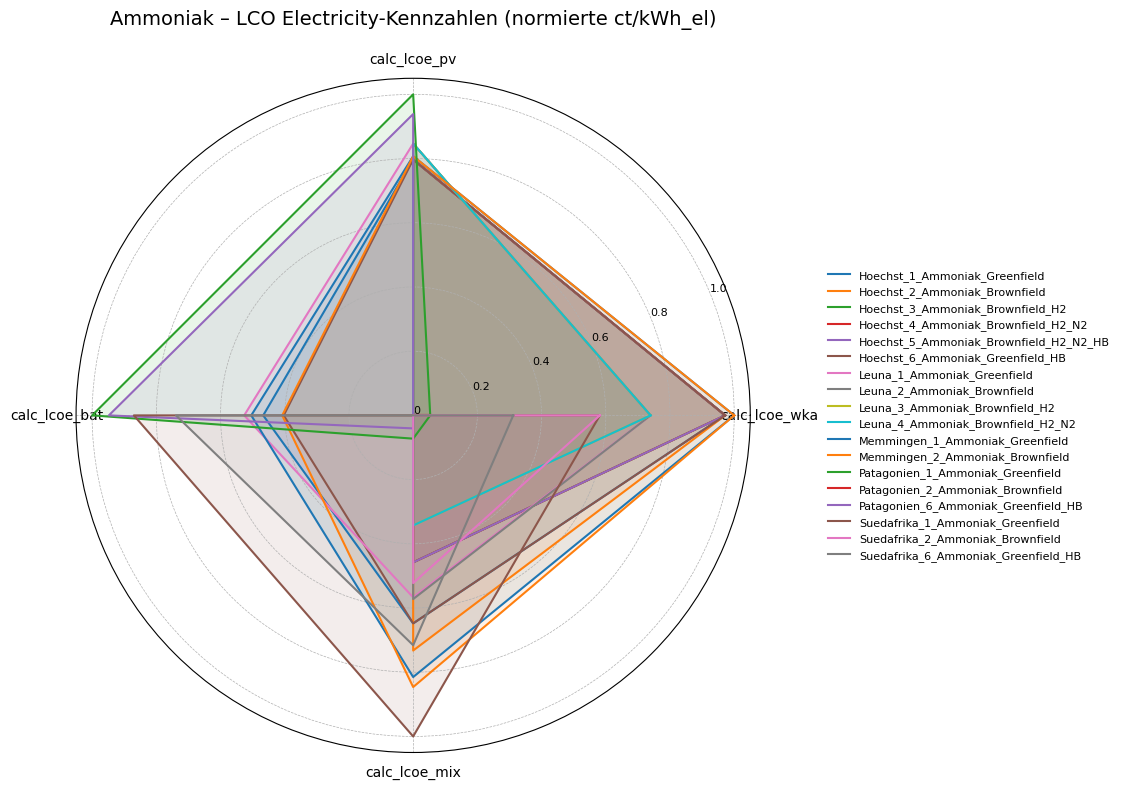

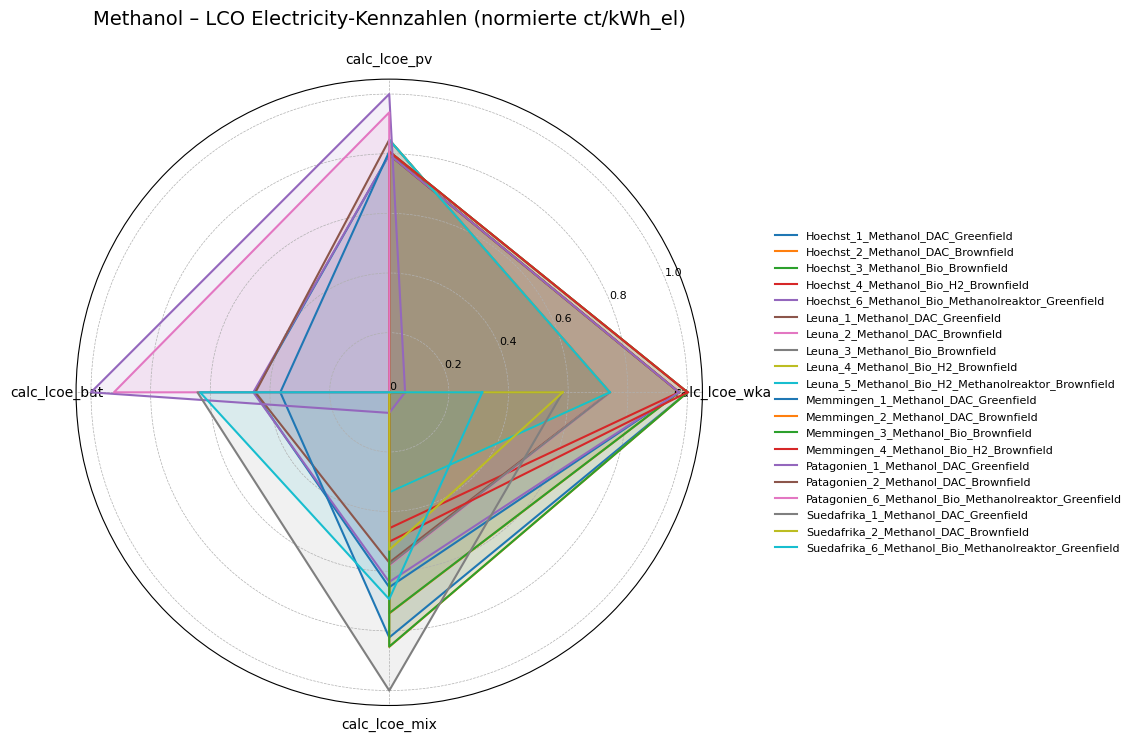

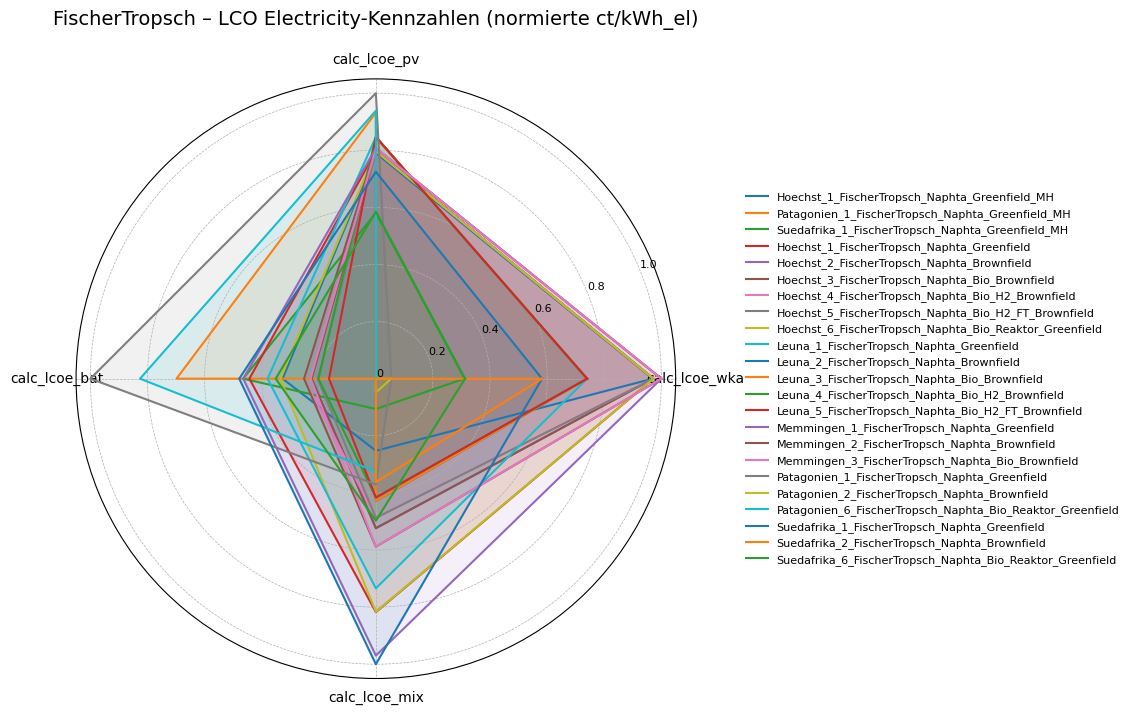

In [11]:
plot_spiderwebs_by_group(
    df_wide,
    spider_vars=[
        "calc_lcoe_wka",
        "calc_lcoe_pv",
        "calc_lcoe_bat",
        "calc_lcoe_mix",
        "calc_lcose_ges"
    ],
    save_path_template="Vergleich_Bilder/LCO/Spider/spider_{group}_{varlist}.png",
    title_template="{group} – LCO Electricity-Kennzahlen (normierte ct/kWh_el)"
)

#### LCOE Wind

In [12]:
plot_modelvergleich(
    parameter="calc_lcoe_wka",
    farbe=col_wka,
    xlim=(0, 6),
    ylim=(-0.5, 46.5),
    save_path="Vergleich_Bilder/LCO/calc_lcoe_wka_bar.png",
    xlabel="Levelized cost of Wind in ct/kWh",
    title="Levelized Cost of Wind",
    multiplikator=1
)

⚠️ Keine Modelle mit Parameter 'calc_lcoe_wka' gefunden.


#### LCOE PV

In [13]:
plot_modelvergleich(
    parameter="calc_lcoe_pv",
    farbe=col_pv,
    xlim=(0, 10),
    ylim=(-0.5, 46.5),
    save_path="Vergleich_Bilder/LCO/calc_lcoe_pv_bar.png",
    xlabel="Levelized cost of PV in ct/kWh",
    title="Levelized Cost of PV",
    multiplikator=1
)

⚠️ Keine Modelle mit Parameter 'calc_lcoe_pv' gefunden.


#### LCO Battery

In [14]:
plot_modelvergleich(
    parameter="calc_lcoe_bat",
    farbe=col_bat,
    xlim=(0, 45),
    ylim=(-0.5, 46.5),
    save_path="Vergleich_Bilder/LCO/calc_lcoe_bat_bar.png",
    xlabel="Levelized cost of Battery in ct/kWh",
    title="Levelized Cost of Battery",
    multiplikator=1
)

⚠️ Keine Modelle mit Parameter 'calc_lcoe_bat' gefunden.


#### LCOE Strommix ohne import

In [15]:
plot_modelvergleich(
    parameter="calc_lcoe_mix",
    farbe=col_el,
    xlim=(0, 10),
    ylim=(-0.5, 46.5),
    save_path="Vergleich_Bilder/LCO/calc_lcoe_mix_bar.png",
    xlabel="Levelized cost of Electricity-mix in ct/kWh",
    title="Levelized Cost of Electricity-mix",
    multiplikator=1
)

⚠️ Keine Modelle mit Parameter 'calc_lcoe_mix' gefunden.


## 4.2 Heat

### 4.2.1 Gesamtkosten je kWh Heat

In [16]:
plot_modelvergleich(
    parameter="calc_cost_q",
    farbe=col_q,
    xlim=(0, 4),
    ylim=(-0.5, 31.5),
    save_path="Vergleich_Bilder/LCO/calc_cost_q_bar.png",
    xlabel="Levelized cost in ct/kWh_th",
    title="Levelized Cost of Heat",
    multiplikator=100
)

⚠️ Keine Modelle mit Parameter 'calc_cost_q' gefunden.


### 4.2.2 LCO Heat

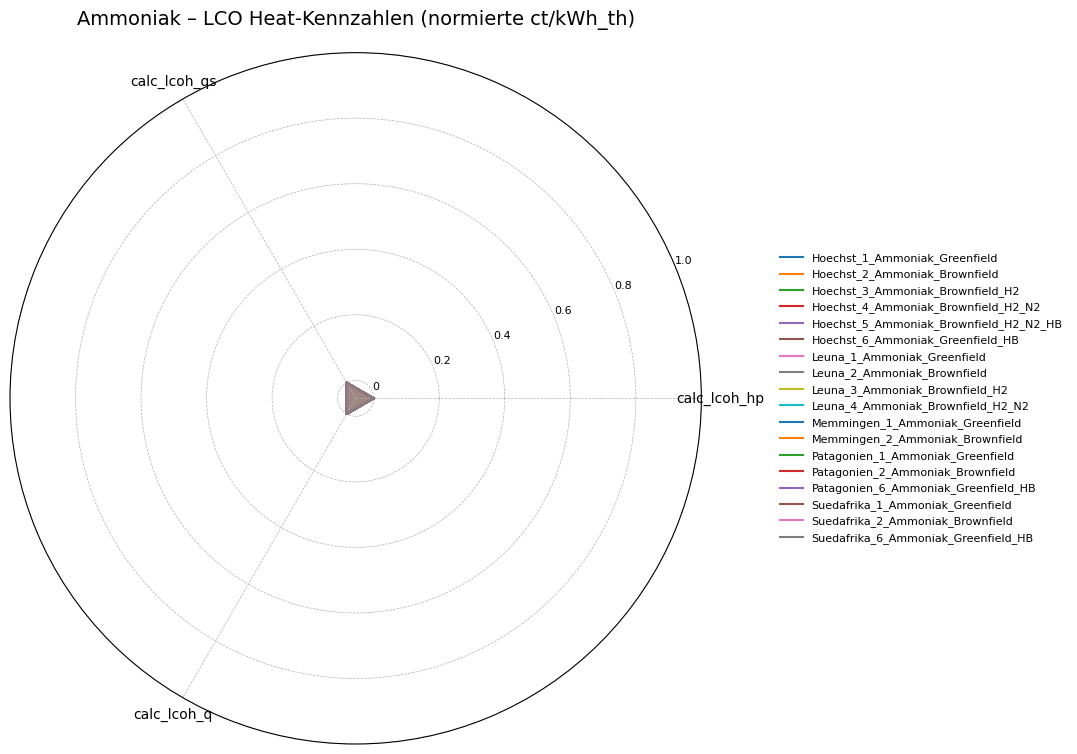

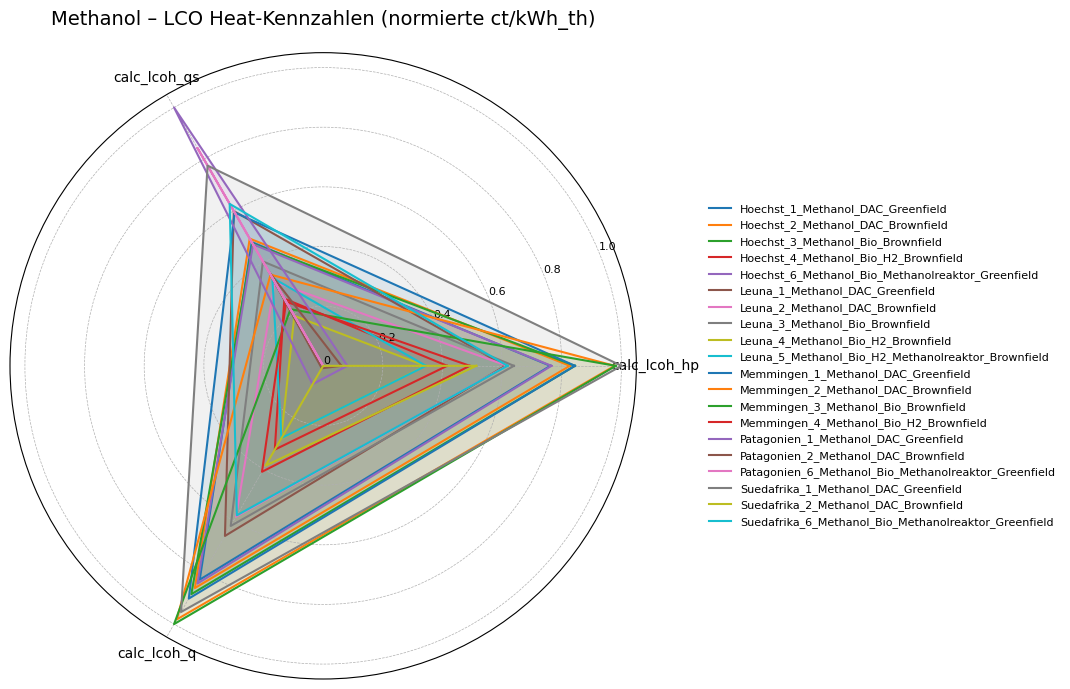

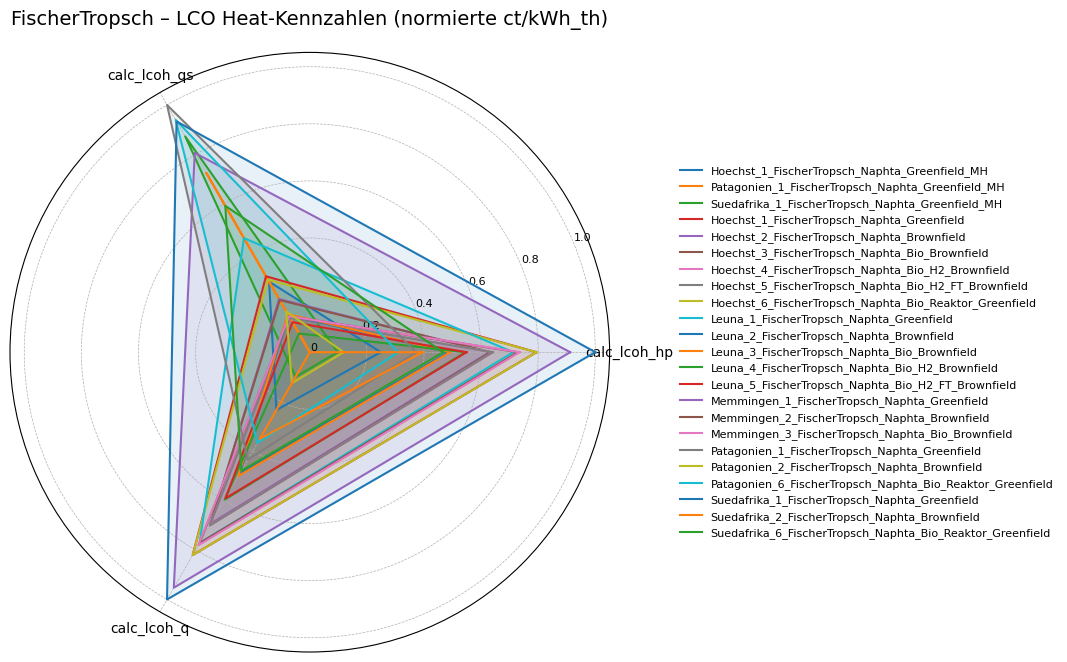

In [17]:
plot_spiderwebs_by_group(
    df_wide,
    spider_vars=[
        "calc_lcoh_hp",
        "calc_lcoh_qs",
        "calc_lcoh_q"
    ],
    save_path_template="Vergleich_Bilder/LCO/Spider/spider_{group}_{varlist}.png",
    title_template="{group} – LCO Heat-Kennzahlen (normierte ct/kWh_th)"
)

#### LCO Heatpump

In [18]:
plot_modelvergleich(
    parameter="calc_lcoh_hp",
    farbe=col_hp,
    xlim=(0, 5),
    ylim=(-0.5, 31.5),
    save_path="Vergleich_Bilder/LCO/calc_lcoh_hp_bar.png",
    xlabel="Levelized cost of Heatpump in ct/kWh_th",
    title="Levelized Cost of Heatpump",
    multiplikator=1
)

⚠️ Keine Modelle mit Parameter 'calc_lcoh_hp' gefunden.


#### LCO Heatstorage

In [19]:
plot_modelvergleich(
    parameter="calc_lcoh_qs",
    farbe=col_qs,
    xlim=(0, 5),
    ylim=(-0.5, 31.5),
    save_path="Vergleich_Bilder/LCO/calc_lcoh_qs_bar.png",
    xlabel="Levelized cost of Heatstorage in ct/kWh_th",
    title="Levelized Cost of Heatstorage",
    multiplikator=1
)

⚠️ Keine Modelle mit Parameter 'calc_lcoh_qs' gefunden.


#### LCO Heat Mix

In [20]:
plot_modelvergleich(
    parameter="calc_lcoh_q",
    farbe=col_qs,
    xlim=(0, 5),
    ylim=(-0.5, 31.5),
    save_path="Vergleich_Bilder/LCO/calc_lcoh_q_bar.png",
    xlabel="Levelized cost of Heat in ct/kWh_th",
    title="Levelized Cost of Heat",
    multiplikator=1
)

⚠️ Keine Modelle mit Parameter 'calc_lcoh_q' gefunden.


## 4.3 Hydrogen

### 4.3.1 Gesamtkosten je kg H2

In [21]:
plot_modelvergleich(
    parameter="calc_cost_h2",
    farbe=col_h2,
    xlim=(0, 15),
    ylim=(-0.5, 46.5),
    save_path="Vergleich_Bilder/LCO/calc_cost_h2_bar.png",
    xlabel="Levelized cost in €/kg_H2",
    title="Levelized Cost of Hydrogen",
    multiplikator=1
)

⚠️ Keine Modelle mit Parameter 'calc_cost_h2' gefunden.


### 4.3.2 LCO Hydrogen

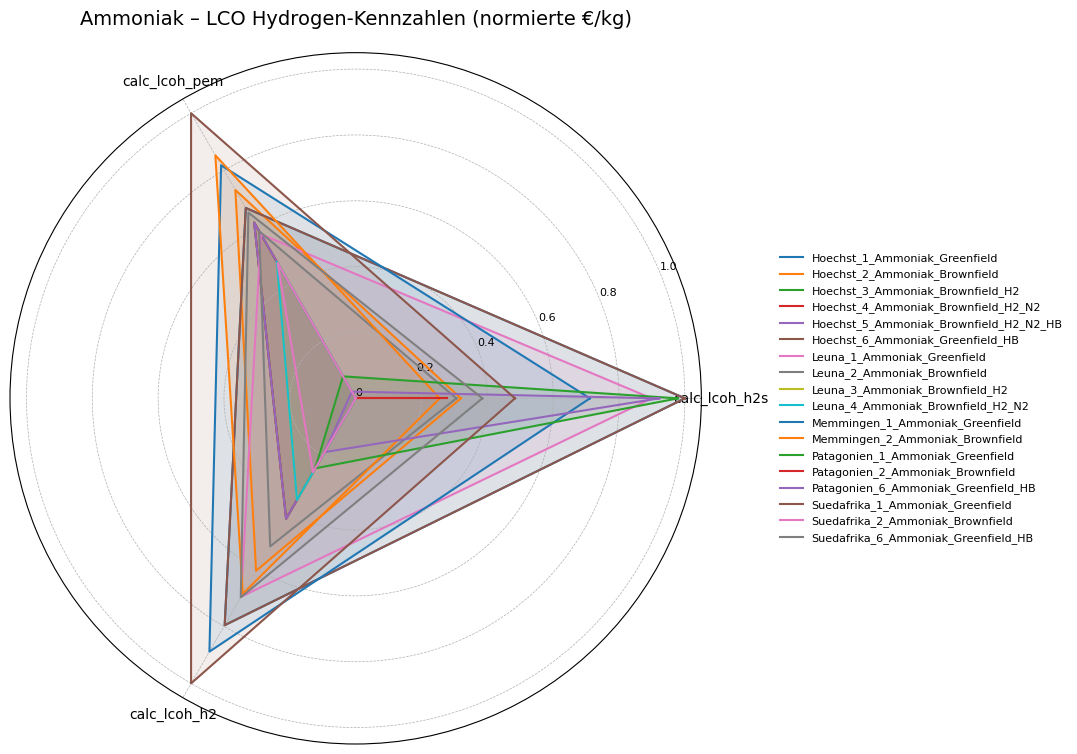

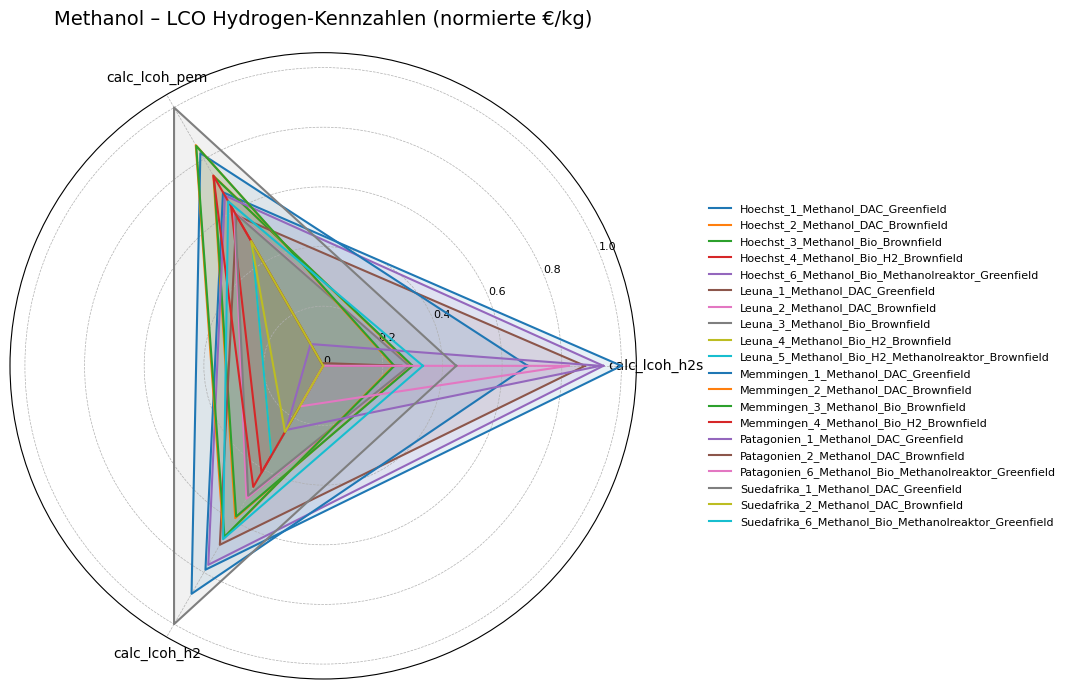

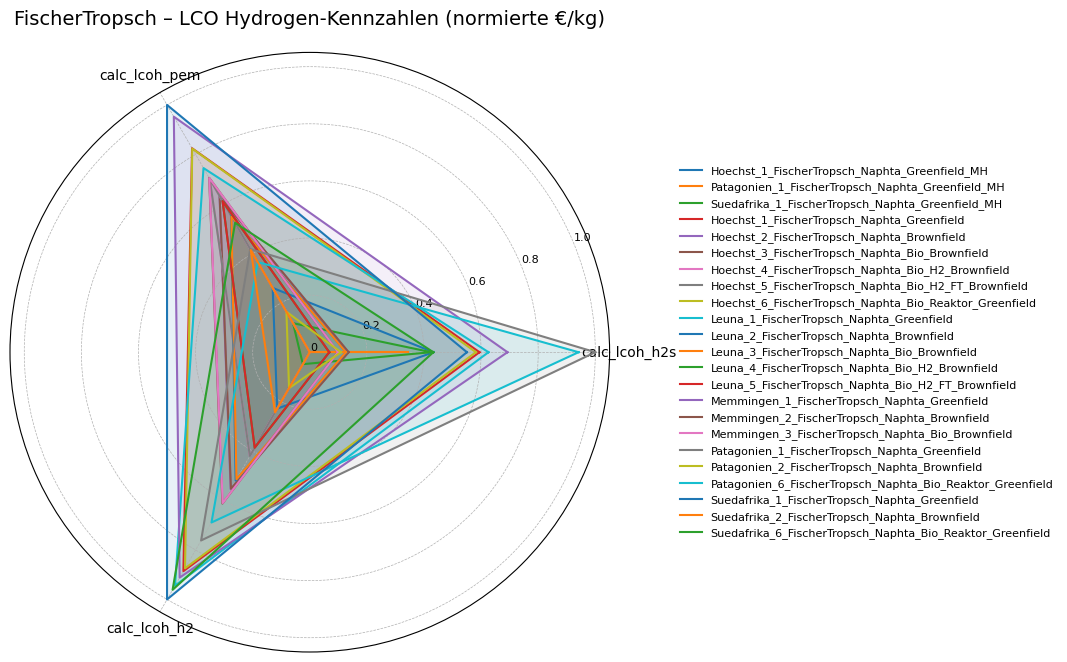

In [22]:
plot_spiderwebs_by_group(
    df_wide,
    spider_vars=[
        "calc_lcoh_h2s",
        "calc_lcoh_pem",
        "calc_lcoh_h2",
        "calc_lcosh_ges"
    ],
    save_path_template="Vergleich_Bilder/LCO/Spider/spider_{group}_{varlist}.png",
    title_template="{group} – LCO Hydrogen-Kennzahlen (normierte €/kg)"
)

#### LCOH Storage

In [23]:
plot_modelvergleich(
    parameter="calc_lcoh_h2s",
    farbe=col_h2s,
    xlim=(0, 15),
    ylim=(-0.5, 46.5),
    save_path="Vergleich_Bilder/LCO/calc_lcoh_h2s_bar.png",
    xlabel="Levelized cost of Hydrogen Storage in €/kg_H2",
    title="Levelized Cost of Hydrogen Storage",
    multiplikator=1
)

⚠️ Keine Modelle mit Parameter 'calc_lcoh_h2s' gefunden.


#### LCOH PEM

In [24]:
plot_modelvergleich(
    parameter="calc_lcoh_pem",
    farbe=col_pem,
    xlim=(0, 10),
    ylim=(-0.5, 46.5),
    save_path="Vergleich_Bilder/LCO/calc_lcoh_pem_bar.png",
    xlabel="Levelized cost of PEM in €/kg_H2",
    title="Levelized Cost of PEM",
    multiplikator=1
)

⚠️ Keine Modelle mit Parameter 'calc_lcoh_pem' gefunden.


#### LCOH Mix ohne import

In [25]:
plot_modelvergleich(
    parameter="calc_lcoh_h2",
    farbe=col_h2,
    xlim=(0, 10),
    ylim=(-0.5, 46.5),
    save_path="Vergleich_Bilder/LCO/calc_lcoh_h2_bar.png",
    xlabel="Levelized cost of Hydrogen Mix in €/kg_H2",
    title="Levelized Cost of Hydrogen Mix",
    multiplikator=1
)

⚠️ Keine Modelle mit Parameter 'calc_lcoh_h2' gefunden.


#### LCO System Hydrogen (mit Import)

In [26]:
plot_modelvergleich(
    parameter="calc_lcosh_ges",
    farbe=col_h2,
    xlim=(0, 10),
    ylim=(-0.5, 10.5),
    save_path="Vergleich_Bilder/LCO/calc_lcosh_ges_bar.png",
    xlabel="Levelized cost of System Hydrogen in €/kg_H2",
    title="Levelized Cost of System Hydrogen",
    multiplikator=1
)

⚠️ Keine Modelle mit Parameter 'calc_lcosh_ges' gefunden.


## 4.4 CO2

### 4.4.1 Gesamtkosten je kg

In [27]:
plot_modelvergleich(
    parameter="calc_cost_co2",
    farbe=col_co2,
    xlim=(0, 1),
    ylim=(-0.5, 31.5),
    save_path="Vergleich_Bilder/LCO/calc_cost_co2_bar.png",
    xlabel="Levelized cost in €/kg_CO2",
    title="Levelized Cost of Carbon Dioxide",
    multiplikator=1
)

⚠️ Keine Modelle mit Parameter 'calc_cost_co2' gefunden.


### 4.4.2 LCO CO2

#### LCO MEA

In [28]:
plot_modelvergleich(
    parameter="calc_lcon_mea",
    farbe=col_mea,
    xlim=(0, 0.5),
    ylim=(-0.5, 11.5),
    save_path="Vergleich_Bilder/LCO/calc_lcon_mea_bar.png",
    xlabel="Levelized cost of MEA in €/kg_CO2",
    title="Levelized Cost of MEA",
    multiplikator=1
)

⚠️ Keine Modelle mit Parameter 'calc_lcon_mea' gefunden.


#### LCO DAC

In [29]:
plot_modelvergleich(
    parameter="calc_lcon_dac",
    farbe=col_dac,
    xlim=(0, 0.5),
    ylim=(-0.5, 19.5),
    save_path="Vergleich_Bilder/LCO/calc_lcon_dac_bar.png",
    xlabel="Levelized cost of DAC in €/kg_CO2",
    title="Levelized Cost of DAC",
    multiplikator=1
)

⚠️ Keine Modelle mit Parameter 'calc_lcon_dac' gefunden.


## 4.5 Methanol

### 4.5.1 Gesamtkosten je kg

In [30]:
plot_modelvergleich(
    parameter="calc_cost_ch3oh",
    farbe=col_ch3oh,
    xlim=(0, 2),
    ylim=(-0.5, 15.5),
    save_path="Vergleich_Bilder/LCO/calc_cost_ch3oh_bar.png",
    xlabel="Production cost in €/kg_CH3OH",
    title="Production Cost of Methanol",
    multiplikator=1/1000
)

⚠️ Keine Modelle mit Parameter 'calc_cost_ch3oh' gefunden.


### 4.5.2 LCO Methanol

In [31]:
plot_modelvergleich(
    parameter="calc_lcof_ms",
    farbe=col_ch3oh,
    xlim=(0, 2),
    ylim=(-0.5, 15.5),
    save_path="Vergleich_Bilder/LCO/calc_lcof_ms_bar.png",
    xlabel="Levelized cost of Methanol in €/kg_CH3OH",
    title="Levelized Cost of Methanol",
    multiplikator=1/1000
)

⚠️ Keine Modelle mit Parameter 'calc_lcof_ms' gefunden.


## 4.6 SAF

### 4.6.1 Gesamtkosten je kg

In [32]:
plot_modelvergleich(
    parameter="calc_cost_saf",
    farbe=col_saf,
    xlim=(0, 15),
    ylim=(-0.5, 15.5),
    save_path="Vergleich_Bilder/LCO/calc_cost_saf_bar.png",
    xlabel="Production cost in €/kg_SAF",
    title="Production Cost of SAF",
    multiplikator=1/1000
)

⚠️ Keine Modelle mit Parameter 'calc_cost_saf' gefunden.


### 4.6.2 LCO SAF

#### LCO Naphta

In [33]:
plot_modelvergleich(
    parameter="calc_lcof_naph",
    farbe=col_naph,
    xlim=(0,50),
    ylim=(-0.5, 15.5),
    save_path="Vergleich_Bilder/LCO/calc_lcof_naph_bar.png",
    xlabel="Levelized cost of Naphta in €/kg",
    title="Levelized Cost of Naphta",
    multiplikator=1/1000
)

⚠️ Keine Modelle mit Parameter 'calc_lcof_naph' gefunden.


#### LCO Kerosin

In [34]:
plot_modelvergleich(
    parameter="calc_lcof_saf",
    farbe=col_saf,
    xlim=(0, 20),
    ylim=(-0.5, 15.5),
    save_path="Vergleich_Bilder/LCO/calc_lcof_saf_bar.png",
    xlabel="Levelized cost of SAF in €/kg",
    title="Levelized Cost of SAF",
    multiplikator=1/1000
)

⚠️ Keine Modelle mit Parameter 'calc_lcof_saf' gefunden.


#### LCO Fischer Tropsch (Naphta + Kerosin)

In [35]:
plot_modelvergleich(
    parameter="calc_lcof_ft",
    farbe=col_ft,
    xlim=(0, 8),
    ylim=(-0.5, 15.5),
    save_path="Vergleich_Bilder/LCO/calc_lcof_ft_bar.png",
    xlabel="Levelized cost of FT in €/kg",
    title="Levelized Cost of FT",
    multiplikator=1/1000
)

⚠️ Keine Modelle mit Parameter 'calc_lcof_ft' gefunden.


## 4.7 Ammonia

### 4.7.1 Gesamtkosten je kg

In [36]:
plot_modelvergleich(
    parameter="calc_cost_nh3",
    farbe=col_nh3,
    xlim=(0, 2),
    ylim=(-0.5, 14.5),
    save_path="Vergleich_Bilder/LCO/calc_cost_nh3_bar.png",
    xlabel="Production cost in €/kg_NH3",
    title="Production Cost of Ammonia",
    multiplikator=1/1000
)

⚠️ Keine Modelle mit Parameter 'calc_cost_nh3' gefunden.


### 4.7.2 LCO Ammonia

In [37]:
plot_modelvergleich(
    parameter="calc_lcof_hb",
    farbe=col_nh3,
    xlim=(0, 2),
    ylim=(-0.5, 14.5),
    save_path="Vergleich_Bilder/LCO/calc_lcof_hb_bar.png",
    xlabel="Levelized cost in €/kg_NH3",
    title="Levelized Cost of Ammonia",
    multiplikator=1/1000
)

⚠️ Keine Modelle mit Parameter 'calc_lcof_hb' gefunden.


## 4.8 Nitrogen

### 4.8.1 Gesamtkosten je kg

In [38]:
plot_modelvergleich(
    parameter="calc_cost_n2",
    farbe=col_n2,
    xlim=(0, 0.5),
    ylim=(-0.5, 14.5),
    save_path="Vergleich_Bilder/LCO/calc_cost_n2_bar.png",
    xlabel="Levelized cost of Nitrogen in €/kg",
    title="Levelized Cost of Nitrogen",
    multiplikator=1
)

⚠️ Keine Modelle mit Parameter 'calc_cost_n2' gefunden.


### 4.8.2 LCO ASU

In [39]:
plot_modelvergleich(
    parameter="calc_lcon_asu",
    farbe=col_asu,
    xlim=(0, 0.5),
    ylim=(-0.5, 14.5),
    save_path="Vergleich_Bilder/LCO/calc_lcon_asu_bar.png",
    xlabel="Levelized cost of ASU in €/kg",
    title="Levelized Cost of ASU",
    multiplikator=1
)

⚠️ Keine Modelle mit Parameter 'calc_lcon_asu' gefunden.


## 4.9 Methane

### 4.9.1 Gesamtkosten je kg

In [40]:
plot_modelvergleich(
    parameter="calc_cost_ch4",
    farbe=col_ch4,
    xlim=(0, 4),
    ylim=(-0.5, 15.5),
    save_path="Vergleich_Bilder/LCO/calc_cost_ch4_bar.png",
    xlabel="Production cost in €/kg_CH4",
    title="Production Cost of Methane",
    multiplikator=1/1000
)

⚠️ Keine Modelle mit Parameter 'calc_cost_ch4' gefunden.


### 4.9.2 LCO Methanol

In [41]:
plot_modelvergleich(
    parameter="calc_lcof_mg",
    farbe=col_ch4,
    xlim=(0, 4),
    ylim=(-0.5, 15.5),
    save_path="Vergleich_Bilder/LCO/calc_lcof_mg_bar.png",
    xlabel="Levelized cost of Methane in €/kg_CH4",
    title="Levelized Cost of Methane",
    multiplikator=1/1000
)

⚠️ Keine Modelle mit Parameter 'calc_lcof_mg' gefunden.


# 5 Verkaufspreise

## 5.1 Maximaler Verkaufspreis (ohne Vorverkauf)

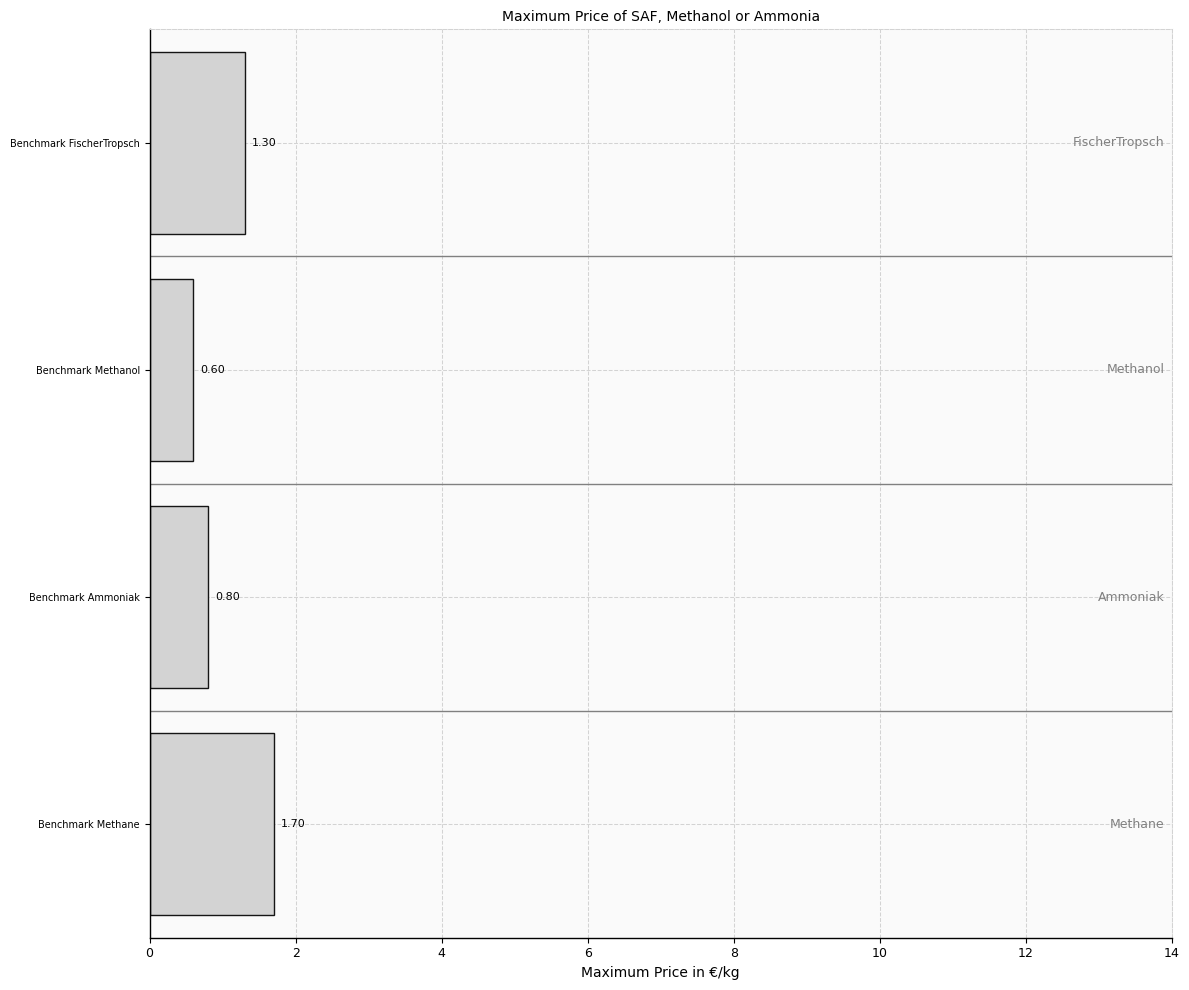

In [42]:
# plot_modelvergleich(
#     parameter="calc_maxprice",
#     farbe=col_sell,
#     xlim=(0, 14),
#     ylim=(-0.5, 36.5),
#     save_path="Vergleich_Bilder/calc_maxprice_bar.png",
#     xlabel="Maximum Price in €/kg",
#     title="Maximum Price of SAF, Methanol or Ammonia",
#     multiplikator=1
# )

benchmark_prices = {
    "Ammoniak": 0.8,
    "Methanol": 0.6,
    "FischerTropsch": 1.3,
    "Methane": 1.7
}

plot_modelvergleich(
    parameter="calc_maxprice",
    farbe=col_sell,
    xlim=(0, 14),
    ylim=(-0.5, 49.5),
    save_path="Vergleich_Bilder/Prices/calc_maxprice_bar.png",
    xlabel="Maximum Price in €/kg",
    title="Maximum Price of SAF, Methanol or Ammonia",
    multiplikator=1,
    benchmark_prices=benchmark_prices
)


## 5.2 Minimaler Verkaufspreis (mit Vorverkauf)

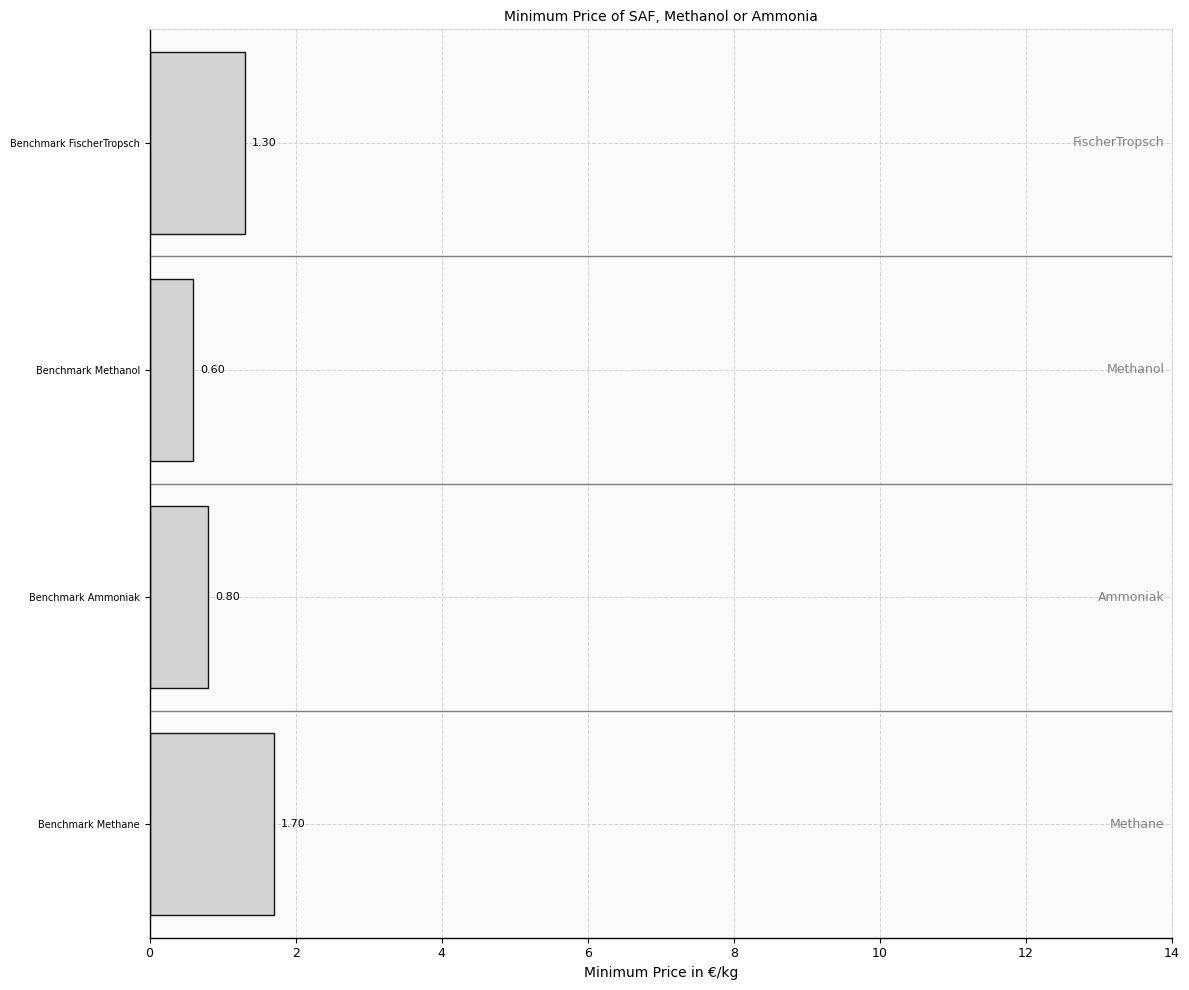

In [43]:
plot_modelvergleich(
    parameter="calc_price",
    farbe=col_sell,
    xlim=(0, 14),
    ylim=(-0.5, 49.5),
    save_path="Vergleich_Bilder/Prices/calc_price_bar.png",
    xlabel="Minimum Price in €/kg",
    title="Minimum Price of SAF, Methanol or Ammonia",
    multiplikator=1,
    benchmark_prices=benchmark_prices
)

## 5.3 Minimale bis Maximale Verkaufspreisspanne

In [44]:
# Definiere die Technologie-Reihenfolge
tech_order = ["Methane","Ammoniak", "Methanol", "FischerTropsch"]

# Technologie zuordnen
def get_tech(name):
    for tech in tech_order:
        if name.startswith(tech) or name.endswith(tech):
            return tech
    return "Sonstige"

# Modelle mit beiden Parametern sammeln
modelle = {
    name: globals()[name]
    for name in globals()
    if isinstance(globals()[name], pd.Series)
    and "calc_price" in globals()[name]
    and "calc_maxprice" in globals()[name]
    and get_tech(name) in tech_order  # nur bekannte Gruppen
}


# Sortieren: nach Technologie, dann -calc_price
modelle_sortiert = sorted(
    modelle.items(),
    key=lambda item: (
        tech_order.index(get_tech(item[0])),
        -item[1]["calc_maxprice"]
    )
)

# Extraktion
categories = [name for name, _ in modelle_sortiert]
min_values = [model["calc_price"] for _, model in modelle_sortiert]
max_values = [model["calc_maxprice"] for _, model in modelle_sortiert]
colors = [col_sell] * len(min_values)  # Einheitliche Farbe

# Trennungslinien berechnen
lines_and_labels = []
last_tech = get_tech(categories[0])
for i, name in enumerate(categories[1:], 1):
    tech = get_tech(name)
    if tech != last_tech:
        lines_and_labels.append((i - 0.5, tech))
        last_tech = tech

# Gruppenbereiche für Hintergrund
group_ranges = []
last_tech = get_tech(categories[0])
start = 0
for i, name in enumerate(categories[1:], 1):
    tech = get_tech(name)
    if tech != last_tech:
        group_ranges.append((start, i, last_tech))
        start = i
        last_tech = tech
group_ranges.append((start, len(categories), last_tech))

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
for i, (cat, v_min, v_max) in enumerate(zip(categories, min_values, max_values)):
    width = v_max - v_min
    bar = ax.barh(y=cat, width=width, left=v_min, color=colors[i], edgecolor='black')
    ax.text(v_max + 0.1,
            i,
            f"{v_min:.2f}–{v_max:.2f}",
            va='center', ha='left', fontsize=8, color='black')

# Stil & Achsen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)
ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

# Trennungslinien + Beschriftung
for y, label in lines_and_labels:
    ax.axhline(y, color='gray', linestyle='-', linewidth=1)

for start, end, tech in group_ranges:
    ax.axhspan(start - 0.5, end - 0.5, facecolor='lightgray', alpha=0.1)
    ax.text(13.9, (start + end - 1) / 2,
            tech, va='center', ha='right', fontsize=9, color='gray')

# Beschriftung
ax.set_xlim(0, 14)
ax.set_ylim(-0.5, len(categories) - 0.5)
plt.xlabel("Price Range in €/kg", fontsize=10)
plt.title("Minimum and Maximum Price of SAF, Methanol or Ammonia", fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig("Vergleich_Bilder/Prices/calc_price_range_bar.png", dpi=300, bbox_inches='tight')
plt.show()


IndexError: list index out of range

# 6 Investitionen

In [ ]:
plot_spiderwebs_by_group(
    df_wide,
    spider_vars=[
        "result_pem_leistung",
        "result_pv_leistung",
        "result_wka_leistung",
        "result_bat_leistung"        
    ],
    save_path_template="Vergleich_Bilder/Invest/spider_{group}_{varlist}.png",
    title_template="{group} – Invest-Kennzahlen (normierte MW_el, MW_th)"
)

## 6.1 PEM

In [ ]:
plot_modelvergleich(
    parameter="result_pem_leistung",
    farbe=col_pem,
    xlim=(0, 60),
    ylim=(-0.5, 46.5),
    save_path="Vergleich_Bilder/Invest/PEM/result_pem_leistung_bar.png",
    xlabel="Installierte Leistung in MW",
    title="Installierte Leistung PEM",
    multiplikator=1/1000
)

In [ ]:
plot_modelvergleich(
    parameter="result_pem_flowsum_elin",
    farbe=col_el,
    xlim=(0, 400),
    ylim=(-0.5, 46.5),
    save_path="Vergleich_Bilder/Invest/PEM/result_pem_flowsum_elin_bar.png",
    xlabel="Strombedarf in GWh/a",
    title="Strombedarf PEM",
    multiplikator=1/1000
)

In [ ]:
plot_modelvergleich(
    parameter="result_pem_flowsum_h2out",
    farbe=col_h2,
    xlim=(0, 8000),
    ylim=(-0.5, 46.5),
    save_path="Vergleich_Bilder/Invest/PEM/result_pem_flowsum_h2out_bar.png",
    xlabel="Wasserstoffproduktion in t/a",
    title="Wasserstoffproduktion PEM",
    multiplikator=1/1000
)

In [ ]:
plot_modelvergleich(
    parameter="calc_gesamtinvest_pem",
    farbe=col_pem,
    xlim=(0, 60),
    ylim=(-0.5, 46.5),
    save_path="Vergleich_Bilder/Invest/PEM/calc_gesamtinvest_pem_bar.png",
    xlabel="Investitionskosten in M€",
    title="Investitionskosten PEM",
    multiplikator=1/1000000
)

In [ ]:
plot_modelvergleich(
    parameter="calc_opex_fix_pem",
    farbe=col_pem,
    xlim=(0, 2),
    ylim=(-0.5, 46.5),
    save_path="Vergleich_Bilder/Invest/PEM/calc_opex_fix_pem_bar.png",
    xlabel="Betriebskosten in M€/a",
    title="Betriebskosten PEM",
    multiplikator=1/1000000
)

In [ ]:
plot_modelvergleich(
    parameter="calc_annuity_pem",
    farbe=col_pem,
    xlim=(0, 10),
    ylim=(-0.5, 46.5),
    save_path="Vergleich_Bilder/Invest/PEM/calc_annuity_pem_bar.png",
    xlabel="Annuität in M€/a",
    title="Annuität PEM",
    multiplikator=1/1000000
)

In [ ]:
plot_modelvergleich(
    parameter="calc_verzinstinvest_pem",
    farbe=col_pem,
    xlim=(0, 200),
    ylim=(-0.5, 46.5),
    save_path="Vergleich_Bilder/Invest/PEM/calc_verzinstinvest_pem_bar.png",
    xlabel="Investitionskosten verzinst in M€/a",
    title="Investitionskosten verzinst PEM",
    multiplikator=1/1000000
)

In [ ]:
plot_modelvergleich(
    parameter="calc_cost_pem",
    farbe=col_pem,
    xlim=(0, 10),
    ylim=(-0.5, 46.5),
    save_path="Vergleich_Bilder/Invest/PEM/calc_cost_pem_bar.png",
    xlabel="Gesamtkosten in M€/a",
    title="Gesamtkosten pro Jahr PEM",
    multiplikator=1/1000000
)

## 6.2 PV

In [ ]:
plot_modelvergleich(
    parameter="result_pv_leistung",
    farbe=col_pv,
    xlim=(0, 40),
    ylim=(-0.5, 47.5),
    save_path="Vergleich_Bilder/Invest/PV/result_pv_leistung_bar.png",
    xlabel="Installierte Leistung in MW",
    title="Installierte Leistung PV",
    multiplikator=1/1000
)

## 6.3 Wind

In [ ]:
plot_modelvergleich(
    parameter="result_wka_leistung",
    farbe=col_wka,
    xlim=(0, 150),
    ylim=(-0.5, 47.5),
    save_path="Vergleich_Bilder/Invest/WKA/result_wka_leistung_bar.png",
    xlabel="Installierte Leistung in MW",
    title="Installierte Leistung Wind",
    multiplikator=1/1000
)

## 6.4 Battery

In [ ]:
plot_modelvergleich(
    parameter="result_bat_kapa",
    farbe=col_bat,
    xlim=(0, 300),
    ylim=(-0.5, 47.5),
    save_path="Vergleich_Bilder/Invest/BAT/result_bat_kapa_bar.png",
    xlabel="Installierte Kapazität in MWh",
    title="Installierte Kapazität Batterie",
    multiplikator=1/1000
)

In [ ]:
plot_modelvergleich(
    parameter="result_bat_leistung",
    farbe=col_bat,
    xlim=(0, 65),
    ylim=(-0.5, 47.5),
    save_path="Vergleich_Bilder/Invest/BAT/result_bat_leistung_bar.png",
    xlabel="Installierte Leistung in MW",
    title="Installierte Leistung Batterie",
    multiplikator=1/1000
)

## 6.5 Wasserstoffspeicher

In [ ]:
plot_modelvergleich(
    parameter="result_h2s_kapa",
    farbe=col_h2s,
    xlim=(0, 30),
    ylim=(-0.5, 46.5),
    save_path="Vergleich_Bilder/Invest/H2S/result_h2s_kapa_bar.png",
    xlabel="Installierte Kapazität in t/h",
    title="Installierte Kapazität Wasserstoffspeicher",
    multiplikator=1/1000
)

## 6.6 ASU

In [ ]:
plot_modelvergleich(
    parameter="result_asu_leistung",
    farbe=col_asu,
    xlim=(0, 75),
    ylim=(-0.5,14.5),
    save_path="Vergleich_Bilder/Invest/ASU/result_asu_leistung_bar.png",
    xlabel="Installierte Leistung in kW",
    title="Installierte Leisung ASU",
    multiplikator=1
)

## 6.7 MEA

## 6.8 CO2

## 6.7 Stromnetz

In [ ]:
plot_modelvergleich(
    parameter="result_stromverkauf_flowsum",
    farbe=col_sell,
    xlim=(0, 150),
    ylim=(-0.5,46.5),
    save_path="Vergleich_Bilder/Invest/Strom/result_stromverkauf_flowsum_bar.png",
    xlabel="Stromverkauf in GWh/a",
    title="Stromverkauf ins Netz",
    multiplikator=1/1000
)

In [ ]:
plot_modelvergleich(
    parameter="result_strombezug_flowsum",
    farbe=col_buy,
    xlim=(0, 100),
    ylim=(-0.5,46.5),
    save_path="Vergleich_Bilder/Invest/Strom/result_strombezug_flowsum_bar.png",
    xlabel="Stromeinkauf in GWh/a",
    title="Stromeinkauf aus dem Netz",
    multiplikator=1/1000
)

## 6.8